<a href="https://colab.research.google.com/github/Joaoplims/NLP-HandsOn/blob/dev/HOF02/HOF02_IntentionalityFilter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Download dados (brutos)

In [5]:
def convert_github_blob_to_raw(url: str) -> str:
    """
    Converts a GitHub blob URL to a raw usercontent URL.
    Example:
    From: https://github.com/user/repo/blob/main/file.csv
    To:   https://raw.githubusercontent.com/user/repo/main/file.csv
    """
    if "github.com" in url and "/blob/" in url:
        url = url.replace("github.com", "raw.githubusercontent.com")
        url = url.replace("/blob/", "/")
    return url

# Example usage:
test_url = "https://github.com/Joaoplims/NLP-HandsOn/blob/main/HOF02/spam.csv"
raw_url = convert_github_blob_to_raw(test_url)
print(f"Raw URL: {raw_url}")

Raw URL: https://raw.githubusercontent.com/Joaoplims/NLP-HandsOn/main/HOF02/spam.csv


In [6]:
import pandas as pd
from datasets import load_dataset
import kagglehub
import os
import glob

def process_url_and_create_df(dataset_item: dict) -> pd.DataFrame | None:
    """
    Loads data based on the source specified in the dataset_item dictionary.
    Supports: 'Github', 'Hugging Face', and 'Kaggle'.
    """
    source = dataset_item.get('source')
    address = dataset_item.get('address')

    try:
        if source == "Github":
            print(f"Downloading directly from GitHub: {address}")
            try:
                return pd.read_csv(address)
            except UnicodeDecodeError:
                print("UTF-8 decoding failed. Retrying with latin-1 encoding...")
                return pd.read_csv(address, encoding='latin-1')

        elif source == "Hugging Face":
            print(f"Loading Hugging Face dataset: {address}")
            ds = load_dataset(address)
            if hasattr(ds, 'keys'):
                split_name = 'train' if 'train' in ds else list(ds.keys())[0]
                return ds[split_name].to_pandas()
            return ds.to_pandas()

        elif source == "Kaggle":
            print(f"Downloading Kaggle dataset: {address}")
            path = kagglehub.dataset_download(address)
            print(f"Path to dataset files: {path}")

            # Search for CSV or JSONL files
            csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
            jsonl_files = glob.glob(os.path.join(path, "**", "*.jsonl"), recursive=True)

            if csv_files:
                print(f"Found CSV: {os.path.basename(csv_files[0])}")
                return pd.read_csv(csv_files[0])
            elif jsonl_files:
                print(f"Found JSONL: {os.path.basename(jsonl_files[0])}")
                return pd.read_json(jsonl_files[0], lines=True)
            else:
                all_files = glob.glob(os.path.join(path, "**", "*"), recursive=True)
                print(f"No supported files found. Files available: {[os.path.basename(f) for f in all_files if os.path.isfile(f)]}")
                return None

        else:
            print(f"Unsupported source: {source}")
            return None

    except Exception as e:
        print(f"Error loading from {source} ({address}): {e}")
        return None

In [7]:
import pandas as pd

# Updated list with structured sources
dataset_urls = [
    {"source": "Github", "address": "https://raw.githubusercontent.com/Joaoplims/NLP-HandsOn/main/HOF02/spam.csv"},
    {"source": "Github", "address": "https://media.githubusercontent.com/media/RockENZO/data/refs/heads/main/Synthetic-Data-for-Scam-Detection-Leveraging-LLMs-to-Train-Deep-Learning-Models-main/data/single-agent-scam-dialogue_train.csv"},
    {"source": "Github", "address": "https://media.githubusercontent.com/media/RockENZO/data/refs/heads/main/Synthetic-Data-for-Scam-Detection-Leveraging-LLMs-to-Train-Deep-Learning-Models-main/data/multi_agent_conversation_train.csv"},
    {"source": "Hugging Face", "address": "wangyuancheng/discord-phishing-scam-clean"},
    {"source": "Kaggle", "address": "kanishkaranaweera/synthetic-dialogue-dataset-romance-scam-detection"}
]
trainDataset_urls=[
     {"source": "Github", "address": "https://raw.githubusercontent.com/BothBosu/Synthetic-Data-for-Scam-Detection-Leveraging-LLMs-to-Train-Deep-Learning-Models/refs/heads/main/data/multi_agent_conversation_test.csv"},
]
indexDataset = 2
item = dataset_urls[indexDataset]
scam_conversations_df = process_url_and_create_df(item)

if scam_conversations_df is not None:
    print(f"Successfully loaded dataset from {item['source']}:")
    display(scam_conversations_df.head())
else:
    print(f"Failed to load the dataset from {item['address']}.")

Successfully loaded dataset from Github:


,dialogue,personality,type,labels
0,"Innocent: Hello. Suspect: Hi, this is Karen f...",aggressive,appointment,0
1,"Innocent: Hello. Suspect: Hi, this is Karen f...",aggressive,appointment,0
2,"Innocent: Hello. Suspect: Hi, this is Karen f...",aggressive,appointment,0
3,"Innocent: Hello. Suspect: Hi, this is Rachel ...",aggressive,appointment,0
4,"Innocent: Hello. Suspect: Hi, this is Karen f...",aggressive,appointment,0


## EDA com os dados brutos



--- EDA: Class Balance and Scam Type Distribution ---



,count
type,
appointment,160
delivery,160
insurance,160
refund,160
reward,160
ssn,160
support,160
wrong,160



--- EDA: Word Clouds by Scam Type (Linguistic Patterns) ---



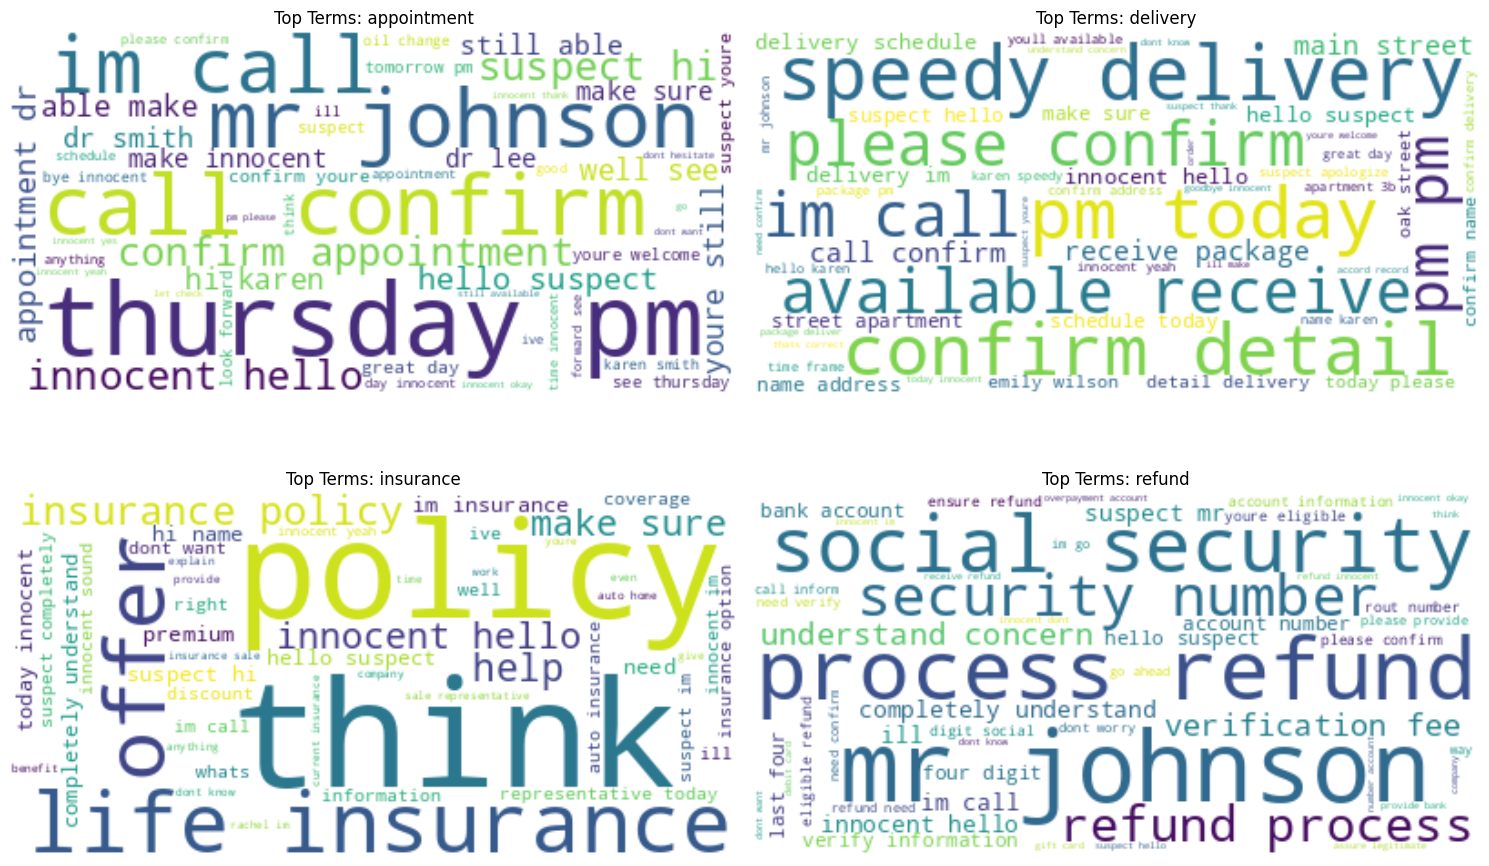


--- EDA: Conversation Size Analysis ---



,mean,median,std,max
type,,,,
appointment,290.36250,308.5,169.315770,934
delivery,362.81875,353.5,158.420262,963
insurance,691.13125,568.0,407.684304,1955
refund,657.39375,517.0,342.335230,1834
reward,618.48750,459.5,379.965043,2218
ssn,654.51250,513.5,322.395144,1712
support,775.95000,595.5,378.769736,1874
wrong,147.40000,130.0,49.422730,349


In [17]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

if scam_conversations_df is not None:
    print("\n--- EDA: Class Balance and Scam Type Distribution ---\n")
    if 'type' in scam_conversations_df.columns:
        type_counts = scam_conversations_df['type'].value_counts()
        display(type_counts)

    # Nova Técnica de EDA: Word Clouds por Tipo de Golpe
    print("\n--- EDA: Word Clouds by Scam Type (Linguistic Patterns) ---\n")
    if 'dialogue' in scam_conversations_df.columns and 'type' in scam_conversations_df.columns:
        # Selecionando os 4 tipos mais comuns para visualização
        top_types = scam_conversations_df['type'].value_counts().nlargest(4).index

        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        axes = axes.flatten()

        for i, scam_type in enumerate(top_types):
            # Agrupa o texto normalizado para aquele tipo
            text = " ".join(normalized_msg[scam_conversations_df['type'] == scam_type])
            wordcloud = WordCloud(width=400, height=200, background_color='white', max_words=50).generate(text)

            axes[i].imshow(wordcloud, interpolation='bilinear')
            axes[i].set_title(f"Top Terms: {scam_type}")
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()

    print("\n--- EDA: Conversation Size Analysis ---\n")
    if 'dialogue' in scam_conversations_df.columns:
        scam_conversations_df['num_words'] = scam_conversations_df['dialogue'].apply(lambda x: len(str(x).split()))
        if 'type' in scam_conversations_df.columns:
            display(scam_conversations_df.groupby('type')['num_words'].agg(['mean', 'median', 'std', 'max']))
else:
    print("DataFrame not loaded.")

## Text Processing

In [5]:
# Install necessary libraries
!pip install unidecode

# Download NLTK data
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')
# Ensure the necessary NLTK data is downloaded
nltk.download('averaged_perceptron_tagger')
# Download Scikit-Learn
!pip install -U scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 5.4 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 23.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


In [37]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.tag import pos_tag

# Baixa os conjuntos de dados necessários se ainda não foram baixados
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng')

# Função auxiliar para mapear as POS tags do NLTK para as tags da WordNet
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def normalize_text(text):
    """Remove pontuação, stopwords, marcadores de leakage, realiza POS-tagging e lematiza."""
    # 1. Remover pontuação
    translator = str.maketrans('', '', string.punctuation)
    text_no_punct = text.translate(translator)

    # 2. Converter para minúsculas e tokenizar
    words = text_no_punct.lower().split()

    # 3. Definir termos de Data Leakage para remoção
    # Incluímos os nomes das classes, marcadores estruturais e nomes próprios comuns no dataset
    leaked_terms = {
        'innocent', 'suspect', 'appointment', 'delivery', 'insurance',
        'refund', 'reward', 'ssn', 'support', 'wrong', 'karen', 'rachel',
        'johnson', 'lee', 'smith', 'sarah', 'mike', 'emily'
    }

    # 4. Remover stopwords e termos de leakage
    stop_words = set(stopwords.words('english'))
    filtered_words = [word for word in words if word not in stop_words and word not in leaked_terms]

    # 5. POS-tagging
    pos_tagged_words = pos_tag(filtered_words)

    # 6. Lematização
    lemmatizer = WordNetLemmatizer()
    lemmatized_words = []
    for word, tag in pos_tagged_words:
        wntag = get_wordnet_pos(tag)
        lemmatized_words.append(lemmatizer.lemmatize(word, wntag))

    return ' '.join(lemmatized_words)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [39]:
# Cada mensagem está tokenizada em seu respectivo vetor
normalized_msg = scam_conversations_df["dialogue"].apply(normalize_text)
print(scam_conversations_df["dialogue"][5])
print(normalized_msg[5])

Innocent: Hello.  Suspect: Hi, this is Karen from Smithville Services. I'm calling to confirm your upcoming appointment with Dr. Lee on Friday at 2 PM. Can you please confirm that you're still able to make it? Innocent: What's the point of confirming? You people are always rescheduling or canceling at the last minute. What's the real reason you're calling? Suspect: I understand your concern, Mr. Johnson. I apologize if we've had to reschedule or cancel in the past. But I assure you, my purpose today is simply to confirm your appointment and make sure you're still available. We want to ensure that everything runs smoothly on Friday. Can you please confirm that you're still able to make it at 2 PM? Innocent: Save it, Karen. I don't pay you to make excuses. Yes, I'll be there. But if Dr. Lee is running behind like usual, I'm walking out. Suspect: Understood, Mr. Johnson. I've noted that you'll be keeping your appointment on Friday at 2 PM. I'll also make a note to remind Dr. Lee's office 

## Representação Vetorial

### TF-IDF


In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# O TfidfVectorizer espera uma lista de strings.
# Como a função normalize_text já retorna strings prontas, usamos a Series diretamente.
tfidf_vectorizer = TfidfVectorizer()

# Ajusta e transforma as mensagens contidas em normalized_msg
tfidf_matrix = tfidf_vectorizer.fit_transform(normalized_msg)

# Converte para DataFrame para visualização
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

print(f"Representação TF-IDF implementada com sucesso.")
print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")

Representação TF-IDF implementada com sucesso.
TF-IDF Matrix Shape: (1280, 5649)


In [42]:
import numpy as np

# Selecionando a primeira linha do dataframe TF-IDF
primeira_msg_tfidf = tfidf_df.iloc[160]

# Filtrando apenas termos com peso maior que zero e ordenando
termos_relevantes = primeira_msg_tfidf[primeira_msg_tfidf > 0].sort_values(ascending=False)

print("Top 10 termos mais relevantes da primeira mensagem (TF-IDF > 0):")
display(termos_relevantes.head(10))

# Calculando a esparsidade
non_zero = np.count_nonzero(tfidf_matrix.toarray())
total = tfidf_matrix.shape[0] * tfidf_matrix.shape[1]
esparsidade = (1 - (non_zero / total)) * 100

print(f"\nTotal de termos no vocabulário: {tfidf_matrix.shape[1]}")
print(f"Esparsidade da matriz: {esparsidade:.2f}% ")

Top 10 termos mais relevantes da primeira mensagem (TF-IDF > 0):


,160
warehouse,0.371061
package,0.304189
return,0.246510
4b,0.180944
doorstep,0.176061
apt,0.176061
available,0.174513
arrange,0.153469
frame,0.143072
babysitting,0.141001



Total de termos no vocabulário: 5649
Esparsidade da matriz: 97.67% 


### Word2Vec

In [30]:
!pip install gensim


In [31]:
from gensim.models import Word2Vec
import numpy as np

# 1. Preparar os dados: Word2Vec espera uma lista de listas de tokens
tokenized_sentences = [msg.split() for msg in normalized_msg]

# 2. Treinar o modelo Word2Vec
# vector_size: dimensão do vetor (ex: 100)
# window: distância máxima entre a palavra atual e a prevista
# min_count: ignora palavras com frequência total inferior a esta
w2v_model = Word2Vec(sentences=tokenized_sentences, vector_size=100, window=5, min_count=1, workers=4)

# 3. Função para criar o vetor médio de uma mensagem
def get_average_word2vec(tokens, model, vector_size):
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
    if not valid_vectors:
        return np.zeros(vector_size)
    return np.mean(valid_vectors, axis=0)

# 4. Gerar os vetores para todas as mensagens
w2v_vectors = np.array([get_average_word2vec(tokens, w2v_model, 100) for tokens in tokenized_sentences])

print(f"Modelo Word2Vec treinado com sucesso.")
print(f"Tamanho do vocabulário: {len(w2v_model.wv)}")
print(f"Shape da matriz de vetores das mensagens: {w2v_vectors.shape}")

# Exemplo: Palavras mais similares a 'money' ou 'appointment' (se existirem)
for word in ['appointment', 'confirm']:
    if word in w2v_model.wv:
        print(f"\nPalavras mais similares a '{word}':")
        display(w2v_model.wv.most_similar(word, topn=5))

Modelo Word2Vec treinado com sucesso.
Tamanho do vocabulário: 5666
Shape da matriz de vetores das mensagens: (1280, 100)

Palavras mais similares a 'appointment':


[('past', 0.8151713609695435),
 ('30minute', 0.814344584941864),
 ('cybersecurity', 0.8106465339660645),
 ('30day', 0.8032638430595398),
 ('750', 0.8012547492980957)]


Palavras mais similares a 'confirm':


[('11am', 0.6965253949165344),
 ('upcoming', 0.6800448298454285),
 ('verify', 0.6769462823867798),
 ('schedule', 0.6554174423217773),
 ('full', 0.6370304822921753)]

## Modelos de classificação

### Naive Bayes

#### Treinamento com Dados Totais e Teste Externo

Modelo treinado com sucesso em todo o conjunto de treino original.
Processando e normalizando os dados de teste...

--- Resultados no Dataset de Teste Externo ---
              precision    recall  f1-score   support

 appointment       1.00      1.00      1.00        40
    delivery       1.00      1.00      1.00        40
   insurance       1.00      1.00      1.00        40
      refund       1.00      1.00      1.00        40
      reward       1.00      1.00      1.00        40
         ssn       1.00      1.00      1.00        40
     support       1.00      1.00      1.00        40
       wrong       1.00      1.00      1.00        40

    accuracy                           1.00       320
   macro avg       1.00      1.00      1.00       320
weighted avg       1.00      1.00      1.00       320



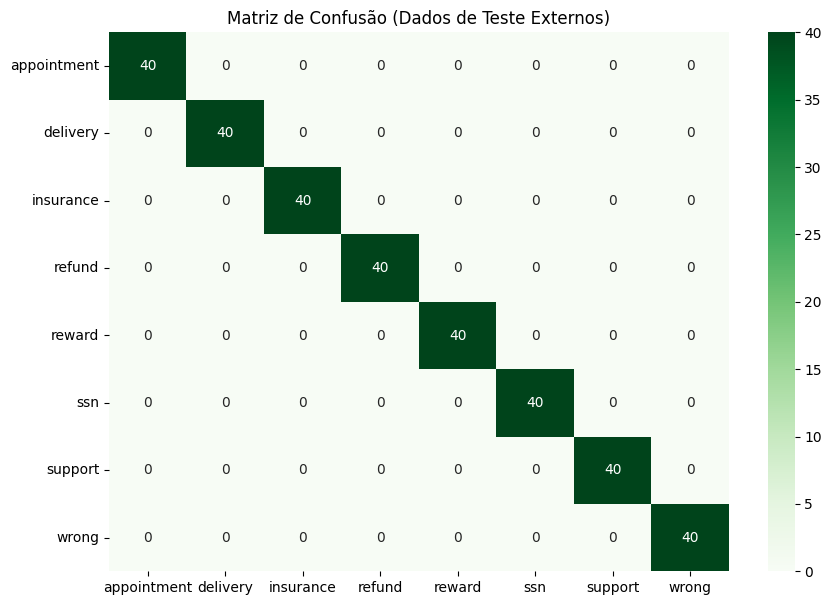

In [43]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Treinar com todos os dados atuais (X, y já definidos globalmente)
final_nb_model = MultinomialNB()
final_nb_model.fit(tfidf_matrix, scam_conversations_df['type'])
print("Modelo treinado com sucesso em todo o conjunto de treino original.")

# 2. Carregar o dataset de teste específico
test_item = trainDataset_urls[0]
scam_test_df = process_url_and_create_df(test_item)

if scam_test_df is not None:
    # 3. Pré-processamento dos dados de teste
    print("Processando e normalizando os dados de teste...")
    normalized_test_msg = scam_test_df["dialogue"].apply(normalize_text)

    # Usamos o .transform (e NÃO .fit_transform) para usar o vocabulário do treino
    X_test_external = tfidf_vectorizer.transform(normalized_test_msg)
    y_test_external = scam_test_df['type']

    # 4. Predição e Avaliação
    y_pred_external = final_nb_model.predict(X_test_external)

    print("\n--- Resultados no Dataset de Teste Externo ---")
    print(classification_report(y_test_external, y_pred_external))

    # Visualização
    plt.figure(figsize=(10, 7))
    cm_ext = confusion_matrix(y_test_external, y_pred_external, labels=final_nb_model.classes_)
    sns.heatmap(cm_ext, annot=True, fmt='d', xticklabels=final_nb_model.classes_, yticklabels=final_nb_model.classes_, cmap='Greens')
    plt.title('Matriz de Confusão (Dados de Teste Externos)')
    plt.show()
else:
    print("Erro ao carregar o dataset de teste.")

#### Investigação de Viés: Termos mais importantes por Classe
Como o modelo atingiu 100% de acurácia, vamos verificar quais palavras o Naive Bayes considera mais determinantes para cada classe. Isso ajuda a identificar se o modelo está apenas decorando padrões sintéticos.

In [35]:
import numpy as np

# Obtendo as classes e os nomes das features (palavras)
classes = final_nb_model.classes_
feature_names = tfidf_vectorizer.get_feature_names_out()

print("--- Top 10 Palavras Determinantes por Categoria ---")

# Para cada classe, encontramos as palavras com as maiores probabilidades logarítmicas
for i, class_label in enumerate(classes):
    top10_indices = np.argsort(final_nb_model.feature_log_prob_[i])[-10:]
    top10_features = [feature_names[idx] for idx in top10_indices]
    print(f"\n[{class_label.upper()}]:")
    print(", ".join(reversed(top10_features)))

print("\nSe palavras como 'suspect', 'innocent' ou nomes repetitivos aparecerem no topo, o modelo está enviesado pela estrutura do dataset sintético.")

--- Top 10 Palavras Determinantes por Categoria ---

[APPOINTMENT]:
thursday, pm, dr, confirm, see, call, still, tomorrow, mr, great

[DELIVERY]:
package, pm, confirm, today, delivery, order, street, schedule, speedy, available

[INSURANCE]:
policy, coverage, im, life, option, current, like, get, auto, would

[REFUND]:
account, process, number, im, information, mr, fee, dont, verification, bank

[REWARD]:
prize, number, dont, sweepstakes, 10000, process, winner, im, youve, select

[SSN]:
social, security, number, im, card, resolve, officer, mr, administration, please

[SUPPORT]:
computer, malware, maam, device, fix, im, access, virus, issue, dont

[WRONG]:
sorry, number, im, dial, must, hows, hey, mistake, plan, think

Se palavras como 'suspect', 'innocent' ou nomes repetitivos aparecerem no topo, o modelo está enviesado pela estrutura do dataset sintético.


### Verificação de Vazamento de Dados (Data Leakage)
Vamos listar termos no vocabulário que coincidem com os nomes das classes ou marcadores estruturais.

In [36]:
import pandas as pd

# Lista de suspeitos: nomes das classes e marcadores estruturais
classes_names = [c.lower() for c in final_nb_model.classes_]
structural_markers = ['suspect', 'innocent']

vocabulary = tfidf_vectorizer.get_feature_names_out()

# Procurando por esses termos exatos no vocabulário
leaked_terms = [word for word in vocabulary if word in classes_names or word in structural_markers]

print(f"Termos encontrados no vocabulário TF-IDF que podem causar leakage:\n{leaked_terms}")

# Verificando a importância desses termos especificamente
feature_log_probs = final_nb_model.feature_log_prob_

leakage_analysis = []
for term in leaked_terms:
    idx = tfidf_vectorizer.vocabulary_.get(term)
    # Verificando em qual classe esse termo é mais forte
    for i, class_label in enumerate(final_nb_model.classes_):
        leakage_analysis.append({
            'term': term,
            'class': class_label,
            'log_prob': feature_log_probs[i][idx]
        })

leak_df = pd.DataFrame(leakage_analysis).sort_values(by='log_prob', ascending=False)
print("\nAnálise de impacto dos termos suspeitos (Top 10):")
display(leak_df.head(10))

Termos encontrados no vocabulário TF-IDF que podem causar leakage:
['appointment', 'delivery', 'refund', 'reward', 'support']

Análise de impacto dos termos suspeitos (Top 10):


,term,class,log_prob
9,delivery,delivery,-5.974704
19,refund,refund,-7.321225
28,reward,reward,-7.532189
25,reward,delivery,-7.850621
26,reward,insurance,-7.983254
0,appointment,appointment,-8.139058
27,reward,refund,-8.382333
24,reward,appointment,-8.471025
31,reward,wrong,-8.706399
30,reward,support,-8.776095
